## LINEAR REGRESSION

### Car Prices

In [1]:
import pandas as pd

In [2]:
car = pd.read_csv("carprices.csv")

In [3]:
car

,Car Model,Mileage,Sell Price($),Age(yrs)
0,BMW X5,69000,18000,6
1,BMW X5,35000,34000,3
2,BMW X5,57000,26100,5
3,BMW X5,22500,40000,2
4,BMW X5,46000,31500,4
5,Audi A5,59000,29400,5
6,Audi A5,52000,32000,5
7,Audi A5,72000,19300,6
8,Audi A5,91000,12000,8
9,Mercedez Benz C class,67000,22000,6


In [4]:
import matplotlib.pyplot as plt

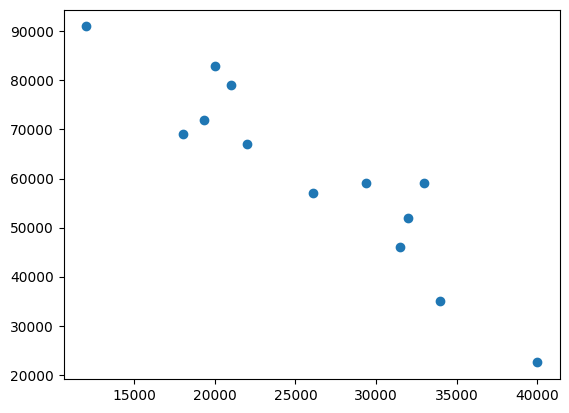

In [5]:
plt.scatter(car["Sell Price($)"], car["Mileage"])

Price and Mileage has negative corelationship. so, linear regression is possible.

In [6]:
from sklearn.linear_model import LinearRegression

In [7]:
LR = LinearRegression()

In [8]:
X = car.drop("Sell Price($)", axis=1)
X

,Car Model,Mileage,Age(yrs)
0,BMW X5,69000,6
1,BMW X5,35000,3
2,BMW X5,57000,5
3,BMW X5,22500,2
4,BMW X5,46000,4
5,Audi A5,59000,5
6,Audi A5,52000,5
7,Audi A5,72000,6
8,Audi A5,91000,8
9,Mercedez Benz C class,67000,6


In [9]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder()
encoded = encoder.fit_transform(car[["Car Model"]]).toarray()
encoded

array([[0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.]])

In [10]:
encoded_df = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out()
)
encoded_df

,Car Model_Audi A5,Car Model_BMW X5,Car Model_Mercedez Benz C class
0,0.0,1.0,0.0
1,0.0,1.0,0.0
2,0.0,1.0,0.0
3,0.0,1.0,0.0
4,0.0,1.0,0.0
5,1.0,0.0,0.0
6,1.0,0.0,0.0
7,1.0,0.0,0.0
8,1.0,0.0,0.0
9,0.0,0.0,1.0


In [11]:
X = pd.concat([encoded_df, car[["Mileage", "Age(yrs)"]]],axis=1)
X

,Car Model_Audi A5,Car Model_BMW X5,Car Model_Mercedez Benz C class,Mileage,Age(yrs)
0,0.0,1.0,0.0,69000,6
1,0.0,1.0,0.0,35000,3
2,0.0,1.0,0.0,57000,5
3,0.0,1.0,0.0,22500,2
4,0.0,1.0,0.0,46000,4
5,1.0,0.0,0.0,59000,5
6,1.0,0.0,0.0,52000,5
7,1.0,0.0,0.0,72000,6
8,1.0,0.0,0.0,91000,8
9,0.0,0.0,1.0,67000,6


In [12]:
y = car["Sell Price($)"]
y

0     18000
1     34000
2     26100
3     40000
4     31500
5     29400
6     32000
7     19300
8     12000
9     22000
10    20000
11    21000
12    33000
Name: Sell Price($), dtype: int64

In [13]:
LR.fit(X,y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


#### price of a mercedez benz that is 4 yr old with mileage 45000


In [14]:
LR.predict([[0,0,1,45000,4]])

C:\Users\nithis kumar\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([36991.31721061])

#### price of a BMW X5 that is 7 yr old with mileage 86000


In [15]:
LR.predict([[0,1,0,86000,7]])

C:\Users\nithis kumar\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([11080.74313219])

#### score (accuracy) of the model

In [16]:
LR.score(X,y)

0.9417050937281083

## SIMPLE LINEAR REGRESSION

In [17]:
can = pd.read_csv("canada_per_capita_income.csv")
can

,year,per capita income (US$)
0,1970,3399.299037
1,1971,3768.297935
2,1972,4251.175484
3,1973,4804.463248
4,1974,5576.514583
5,1975,5998.144346
6,1976,7062.131392
7,1977,7100.126170
8,1978,7247.967035
9,1979,7602.912681


In [18]:
X = can[["year"]]
y = can["per capita income (US$)"]

In [19]:
from sklearn.model_selection import train_test_split

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X,y,train_size=0.95,shuffle=False)

In [21]:
LR.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [22]:
X_test["pred"] =LR.predict(X_test)

In [23]:
X_test["act"] = y_test

In [24]:
X_test

,year,pred,act
44,2014,36441.505382,41039.89360
45,2015,37274.458989,35175.18898
46,2016,38107.412597,34229.19363


####  per capita income of canadian citizens in year 2020

In [25]:
LR.predict([[2020]])

C:\Users\nithis kumar\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([41439.22702502])

In [26]:
LR.score(X_train,y_train)

0.8776296942851187

## MULTIPLE LINEAR REGRESSION

In [27]:
hir = pd.read_csv("hiring.csv")
hir

,experience,test_score(out of 10),interview_score(out of 10),salary($)
0,NaN,8.0,9,50000
1,NaN,8.0,6,45000
2,five,6.0,7,60000
3,two,10.0,10,65000
4,seven,9.0,6,70000
5,three,7.0,10,62000
6,ten,NaN,7,72000
7,eleven,7.0,8,80000


In [39]:
from word2number import w2n
def wn(X):
    if pd.isna(X):
        return None
    else: 
        try: 
            return w2n.word_to_num(X)
        except:
            return X
hir["experience"] = hir["experience"].apply(wn)
hir

,experience,test_score(out of 10),interview_score(out of 10),salary($)
0,NaN,8.0,9,50000
1,NaN,8.0,6,45000
2,5.0,6.0,7,60000
3,2.0,10.0,10,65000
4,7.0,9.0,6,70000
5,3.0,7.0,10,62000
6,10.0,NaN,7,72000
7,11.0,7.0,8,80000


In [49]:
hir = hir.fillna(hir.mean(numeric_only=True)).round(2)
hir

,experience,test_score(out of 10),interview_score(out of 10),salary($)
0,6.33,8.00,9,50000
1,6.33,8.00,6,45000
2,5.00,6.00,7,60000
3,2.00,10.00,10,65000
4,7.00,9.00,6,70000
5,3.00,7.00,10,62000
6,10.00,7.86,7,72000
7,11.00,7.00,8,80000


In [50]:
X = hir.drop("salary($)", axis=1)
y= hir["salary($)"]

In [51]:
LR.fit(X,y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


#### 2 yr experience, 9 test score, 6 interview score.

In [52]:
LR.predict([[2,9,6]])

C:\Users\nithis kumar\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([47731.64209118])

#### 12 yr experience, 10 test score, 10 interview score.

In [53]:
LR.predict([[12,10,10]])

C:\Users\nithis kumar\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([86443.7409002])

In [54]:
LR.score(X,y)

0.34414413339486905